In [90]:
import numpy as np
import matplotlib.pyplot as plt
import qil_helpers.Ben.General as Ben
import qil_helpers.Ben.Holeburning_analysis as HBA

#from qil_SpinHamiltonian.spin_hamiltonian import hamilFromYAML,eachElemFunc,transitionPixelPlot
import qil_SpinHamiltonian.spin_hamiltonian as spin
import qil_SpinHamiltonian.search as spinSearch

import matplotlib.colors as clr
import glob
import scipy.signal as sig
import re
import scipy as sp
import os
import pandas as pd
from copy import copy
from scipy import integrate,optimize

from IPython.display import display, Latex
from scipy.spatial.transform import Rotation

import plotly.graph_objects as go


In [91]:
Espin=1/2
Ispin=1/2

#Natural units of the program are GHz, T and radians so conversions must be made
#gI=np.diag([3.916,3.916,1.053])
gI=np.diag([3.916,3.916,-1.446])

AI=np.diag([3.0819,3.0819,-0.789])*1e9*spin.h
GR=np.array([0,0,0])*np.pi/180
AR=np.array([0,0,0])*np.pi/180

#No convention for rotation is specified in the data source, but ZYZ is typical
g=spin.tensorRotation(gI,GR,conv='ZYZ')
A=spin.tensorRotation(AI,AR,conv='ZYZ')
print(g)
#Instantiates the class and sets up dimensions and spin matricies
ground = spin.cSpinHamiltonian(Espin,Ispin)

#pass these matricies to the class
ground.setgE(g)
#This will calculate and store the interaction in our static hamiltonian
ground.hyperfineInteraction(A)
print(ground.H.shape) #Access the static hamiltonian it big so lets just print its shape


pass

[[ 3.916  0.     0.   ]
 [ 0.     3.916  0.   ]
 [ 0.     0.    -1.446]]
(4, 4)


[[0.]
 [0.]
 [1.]]


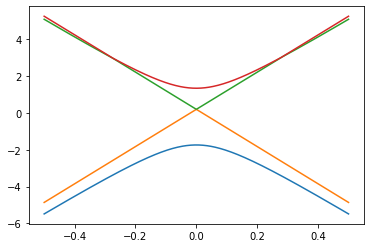

In [92]:
#Rmat=
Bs=np.linspace(-500E-3,500E-3,300)
#uvec=np.matrix([0,0,1])
uvec=spin.sphereUnit([0,0],conv='yz')#np.matrix([0,0,1])
print(uvec)
B=np.outer(uvec,Bs)


H=ground.dynamicH(B)/(spin.h*1E9)
F,V=np.linalg.eigh(H)
#F,V=ground.getEigFreq(H)
plt.plot(Bs,F)
plt.show()

C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


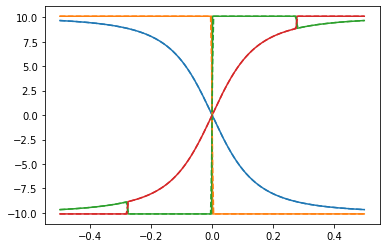

In [93]:
ground.genDerivMatrix()
cFp=ground.gradient(V)

plt.plot(Bs,cFp*uvec)
plt.gca().set_prop_cycle(None)
plt.plot(Bs,np.gradient(F,Bs,axis=0),'--')
plt.show()
#plt.plot()

In [141]:
pts=500
thetas=np.linspace(0,np.pi/2,pts)
phi=np.pi/4#np.pi/3#np.pi/4
phis=np.ones_like(thetas)*phi
xa=thetas


uvec=np.array(spin.sphereUnit(np.array([thetas,phis]).T,conv='yz'))
B=np.array(100E-3*uvec).T
# x=(np.sin(thetas)*np.cos(phis)).flatten()
# y=(np.sin(thetas)*np.sin(phis)).flatten()
# z=(np.cos(thetas)).flatten()
# uvec=np.vstack([x,y,z])


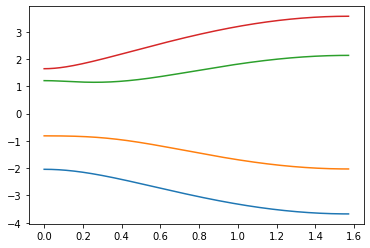

C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


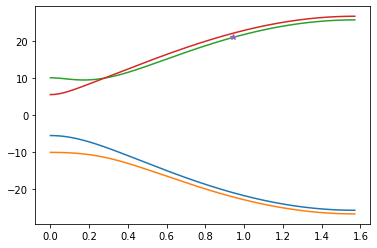

In [142]:
H=ground.dynamicH(B)/(spin.h*1E9)
F,V=np.linalg.eigh(H)
#F,V=ground.getEigFreq(H)
plt.plot(thetas,F)
plt.show()

Fp=ground.gradient(V)
Fpte=np.einsum('kij,kj->ki',Fp,uvec)

plt.plot(thetas,Fpte)
plt.plot(thetas[300],np.dot(Fp[300,2,:],uvec[300,:]),'*')
Fpt=np.dot(Fp,uvec[...,np.newaxis])#np.tensordot(Fp,uvec,axes=2)